### HuggingFace의 모델로 Dynamic Padding(배치별 동적 패딩) vs Bucketing(길이순 배치 구성) 

#### 1. 환경 설정

In [1]:
!pip install -q -U transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.9 MB/s eta 0:00:00


In [1]:
import torch
import numpy as np
import transformers
import datasets

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)

# GPU 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

torch: 2.11.0+cu128
transformers: 5.16.1
datasets: 4.8.5
device: cuda
GPU: Tesla T4


---


#### 2. klue/bert-base 모델 + 토크나이저 로드

In [2]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "klue/bert-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
# num_labels=2: NSMC는 긍정(1)/부정(0) 2가지 클래스

print(model.config.architectures)
print("vocab size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  445MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


['BertForMaskedLM']
vocab size: 32000


---


#### 3. 설계
#### 3-1 raw 파일 다운로드 + 파싱

In [3]:
!mkdir -p data
!wget -nc -q https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt -P data
!wget -nc -q https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt -P data
!wc -l data/ratings_*.txt

   50001 data/ratings_test.txt
  150001 data/ratings_train.txt
  200002 total


In [4]:
import pandas as pd

def parse_nsmc_file(file_path):
    """
    NSMC 파일을 안전하게 파싱하는 함수
    id \t document \t label  (탭 구분, 첫 줄은 헤더)
    """
    data = {'id': [], 'document': [], 'label': []}

    with open(file_path, 'r', encoding='utf-8') as f:
        next(f)  # 헤더 스킵

        for line_num, line in enumerate(f, 1):
            try:
                parts = line.strip('\n').split('\t')
                if len(parts) >= 3:
                    doc_id = parts[0]
                    # document에 탭이 섞여 있을 가능성 대비, 가운데를 전부 document로 합침
                    document = '\t'.join(parts[1:-1])
                    label = int(parts[-1])

                    data['id'].append(doc_id)
                    data['document'].append(document)
                    data['label'].append(label)
                else:
                    print(f"Line {line_num}: Invalid format, skipping")
            except Exception as e:
                print(f"Line {line_num}: Error {e}, skipping")

    return pd.DataFrame(data)


train_df = parse_nsmc_file('data/ratings_train.txt')
test_df = parse_nsmc_file('data/ratings_test.txt')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\n첫 5개 샘플:")
print(train_df.head())

Train shape: (150000, 3)
Test shape: (50000, 3)

첫 5개 샘플:
         id                                           document  label
0   9976970                                아 더빙.. 진짜 짜증나네요 목소리      0
1   3819312                  흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나      1
2  10265843                                  너무재밓었다그래서보는것을추천한다      0
3   9045019                      교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정      0
4   6483659  사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...      1


#####

#### 3-2 결측치·중복 제거

In [5]:
print("--- 정제 전 ---")
print("Train:", len(train_df), "/ 중복 제외 document 수:", train_df['document'].nunique())
print("Test:", len(test_df), "/ 중복 제외 document 수:", test_df['document'].nunique())

# 결측치 제거
train_df = train_df.dropna(subset=['document'])
test_df = test_df.dropna(subset=['document'])

# document 기준 중복 제거
train_df = train_df.drop_duplicates(subset=['document']).reset_index(drop=True)
test_df = test_df.drop_duplicates(subset=['document']).reset_index(drop=True)

print("\n--- 정제 후 ---")
print("Train:", len(train_df))
print("Test:", len(test_df))
print("\n라벨 분포(Train):")
print(train_df['label'].value_counts())

--- 정제 전 ---
Train: 150000 / 중복 제외 document 수: 146183
Test: 50000 / 중복 제외 document 수: 49158

--- 정제 후 ---
Train: 146183
Test: 49158

라벨 분포(Train):
label
0    73342
1    72841
Name: count, dtype: int64


#####

#### 3-3 Train/Val 층화 분할 + Hugging Face Dataset 변환

In [6]:
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split

# train의 80%/20% -> train/validation
train_split, val_split = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['label']   # 라벨 비율 긍/부정을 train/val에 동일하게 유지
)

print("Train:", len(train_split), "/ Val:", len(val_split))
print("\nTrain 라벨 분포:")
print(train_split['label'].value_counts(normalize=True))
print("\nVal 라벨 분포:")
print(val_split['label'].value_counts(normalize=True))

Train: 116946 / Val: 29237

Train 라벨 분포:
label
0    0.50171
1    0.49829
Name: proportion, dtype: float64

Val 라벨 분포:
label
0    0.501727
1    0.498273
Name: proportion, dtype: float64


In [7]:
# pandas DataFrame → Hugging Face DatasetDict로 변환
custom_nsmc_dataset = DatasetDict({
    'train': Dataset.from_pandas(train_split[['document', 'label']], preserve_index=False),
    'validation': Dataset.from_pandas(val_split[['document', 'label']], preserve_index=False),
    'test': Dataset.from_pandas(test_df[['document', 'label']], preserve_index=False),
})

print(custom_nsmc_dataset)
print()
print(custom_nsmc_dataset['train'][0])

DatasetDict({
    train: Dataset({
        features: ['document', 'label'],
        num_rows: 116946
    })
    validation: Dataset({
        features: ['document', 'label'],
        num_rows: 29237
    })
    test: Dataset({
        features: ['document', 'label'],
        num_rows: 49158
    })
})

{'document': '허니잼 예스잼 꿀잼 잼잼', 'label': 1}


#####

#### 3-4 토크나이저로 전처리

In [8]:
def transform(data):
    return tokenizer(
        data['document'],
        truncation=True,
        padding='max_length',   # 고정 패딩선(비교를 위해 과하게..)
        max_length=128,
        return_token_type_ids=False,
    )


custom_dataset = custom_nsmc_dataset.map(transform, batched=True)

custom_train_dataset = custom_dataset['train']
custom_val_dataset = custom_dataset['validation']
custom_test_dataset = custom_dataset['test']

print(custom_train_dataset)
print(custom_train_dataset[0].keys())

Map:   0%|          | 0/116946 [00:00<?, ? examples/s]

Map:   0%|          | 0/29237 [00:00<?, ? examples/s]

Map:   0%|          | 0/49158 [00:00<?, ? examples/s]

Dataset({
    features: ['document', 'label', 'input_ids', 'attention_mask'],
    num_rows: 116946
})
dict_keys(['document', 'label', 'input_ids', 'attention_mask'])


---


#### 4. Trainer 설정 + 학습
#### 4-1 평가 지표 정의

In [11]:
!pip install -q evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00


In [12]:
import numpy as np
from evaluate import load

# MRPC는 metric = load('nyu-mll/glue', 'mrpc'),
# NSMC는 단일 문장 이진분류 -> accuracy가 표준 지표(F1도 같이)
accuracy_metric = load('accuracy')
f1_metric = load('f1')

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels)
    return {"accuracy": acc["accuracy"], "f1": f1["f1"]}

In [26]:
# 4-2 TrainingArguments 설정
from transformers import TrainingArguments

output_dir = './results/nsmc_baseline'

training_arguments = TrainingArguments(
    output_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,     # 8->32로 복원
    per_device_eval_batch_size=64,      # 32->64로 복원
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    report_to="none",
)

##### batch_size=8  → 43,854 스텝  (아까 32였을 때보다 4배 더 많은 스텝)
##### batch_size=32 → 10,962 스텝
##### ->32로 선택함

#####

In [27]:
# 4-3 Trainer 생성 + 학습
trainer = Trainer(
    model=model,
    args=training_arguments,
    train_dataset=custom_train_dataset,
    eval_dataset=custom_val_dataset,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.256243,0.248184,0.901016,0.901538
2,0.172384,0.269987,0.905291,0.905298
3,0.106632,0.330313,0.903000,0.903452


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=10965, training_loss=0.17461313542523887, metrics={'train_runtime': 7187.2169, 'train_samples_per_second': 48.814, 'train_steps_per_second': 1.526, 'total_flos': 2.307733911009792e+16, 'train_loss': 0.17461313542523887, 'epoch': 3.0})

In [28]:
# 4-4 Test셋 최종 평가
test_results = trainer.evaluate(custom_test_dataset)
print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.106632,0.272787,3,0.904695,0.905657


{'eval_loss': 0.272787481546402, 'eval_accuracy': 0.9046950648927946, 'eval_f1': 0.9056565778610121}


---

#### 

#### 파인튜닝 전 vs 후 Accuracy 

In [29]:
# 파인튜닝 전 klue/bert-base accuracy
from transformers import AutoModelForSequenceClassification

untrained_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to("cuda")

before_trainer = Trainer(
    model=untrained_model,
    args=training_arguments,
    eval_dataset=custom_test_dataset,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)

before_result = before_trainer.evaluate()
print("파인튜닝 전(랜덤 초기화된 분류층):", before_result)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Loss,Validation Loss,Epoch,Accuracy,F1
No log,0.685693,0,0.543777,0.631238


파인튜닝 전(랜덤 초기화된 분류층): {'eval_loss': 0.6856930255889893, 'eval_accuracy': 0.5437772081858497, 'eval_f1': 0.6312379762237532}


| 구분 | Accuracy | F1 | Loss |
|---|---|---|---|
| **파인튜닝 전** (랜덤 초기화된 분류층) | 54.38% | 0.631 | 0.686 |
| **파인튜닝 후** (klue/bert-base + NSMC 학습) | 90.47% | 0.906 | 0.273 |
| **개선폭** | **+36.09%p** | +0.275 | -0.413 |

```  
파인튜닝은 이미 일반적인 언어 지식을 학습한 BERT를 
특정 NLP 작업(여기서는 감성분류)에 맞게 추가 학습시키는 과정이다.
그 결과 해당 작업의 성능이 크게 향상된다(Accuracy 36.09%p 상승).

Pre-training
대규모 텍스트
↓
"언어를 이해하는 데 필요한 표현" 학습

Fine-tuning
NSMC
↓
"긍정/부정을 구분하는 데 유용한 표현"으로 조정
```  

---

#### 5. Bucketing

In [30]:
# 5-1 원본 데이터셋 준비 (고정 패딩 없이)
def transform_no_padding(data):
    return tokenizer(
        data['document'],
        truncation=True,
        max_length=128,
        return_token_type_ids=False,
        # padding 인자를 뺌
    )

bucketing_dataset = custom_nsmc_dataset.map(transform_no_padding, batched=True)

bucketing_train_dataset = bucketing_dataset['train']
bucketing_val_dataset = bucketing_dataset['validation']
bucketing_test_dataset = bucketing_dataset['test']

# 패딩 없이 토큰화 -> 문장 길이 다름
print(len(bucketing_train_dataset[0]['input_ids']))
print(len(bucketing_train_dataset[1]['input_ids']))
print(len(bucketing_train_dataset[2]['input_ids']))

Map:   0%|          | 0/116946 [00:00<?, ? examples/s]

Map:   0%|          | 0/29237 [00:00<?, ? examples/s]

Map:   0%|          | 0/49158 [00:00<?, ? examples/s]

10
12
17


In [32]:
# 5-2 Data Collator With Padding
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
# 배치 안에서 긴 문장 기준으로 패딩 → 배치마다 패딩 길이가 다르게 결정

In [33]:
# 5-3 Training Arguments 길이 그룹화
from transformers import TrainingArguments

output_dir = './results/nsmc_bucketing'

training_arguments_bucketing = TrainingArguments(
    output_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,      # 이전과 동일 컨디션
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    train_sampling_strategy="group_by_length",   # 비슷한 길이끼리 묶어서 배치 구성
    report_to="none",
)

In [34]:
# 5-4 Trainer 생성 + 학습
from transformers import Trainer

trainer_bucketing = Trainer(
    model=AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2),
    # 모델 초기화
    args=training_arguments_bucketing,
    train_dataset=bucketing_train_dataset,
    eval_dataset=bucketing_val_dataset,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
    data_collator=data_collator,   # 정해지지 않은 padding
)

trainer_bucketing.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.249398,0.243458,0.899477,0.901220
2,0.181870,0.248059,0.903718,0.905812
3,0.117628,0.302675,0.906283,0.906472


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=10965, training_loss=0.19441724847670946, metrics={'train_runtime': 819.4194, 'train_samples_per_second': 428.154, 'train_steps_per_second': 13.381, 'total_flos': 4319570251384560.0, 'train_loss': 0.19441724847670946, 'epoch': 3.0})

#### 

#### Dynamic Padding(배치별) vs Bucketing

In [27]:
lengths = [len(ids) for ids in bucketing_train_dataset['input_ids']]
import numpy as np
print("평균 실제 토큰 길이:", np.mean(lengths))
print("고정 길이: 128")
print(f"평균적으로 낭비된 PAD 비율: {(1 - np.mean(lengths)/128)*100:.1f}%")

평균 실제 토큰 길이: 22.772365023173087
고정 길이: 128
평균적으로 낭비된 PAD 비율: 82.2%


#####

| 항목 | Dynamic padding | Bucketing | 차이 |
|---|---|---|---|
| 학습 시간 | 119.8분 (약 2시간) | 13.7분 | **8.8배 빠름** |
| 처리 속도 | 48.8 samples/sec | 428.2 samples/sec | 8.8배 |
| 최고 Accuracy | 90.53% (Epoch 2) | 90.63% (Epoch 3) | **+0.10%p** |
| 최고 F1 | 0.9053 | 0.9065 | +0.0012 |

```
Bucketing이 하는 일: 각 배치에 불필요한 PAD 토큰을 덜 넣음
                    → 모델이 실제로 보는 진짜 토큰 내용은 고정 패딩 때와 동일함
                    → 어떤 정보도 버려지거나, 속도나 정확도를 위해 희생되는 것 없음
```

---

#### 문장 비교하기

In [28]:
from transformers import pipeline

# 고정 패딩 모델
classifier_before = pipeline(
    "sentiment-analysis",
    model=trainer.model,          # best 모델 (90.53%)
    tokenizer=tokenizer,
    device=0,
)

# Bucketing 모델
classifier_after = pipeline(
    "sentiment-analysis",
    model=trainer_bucketing.model,  # best 모델 (90.63%)
    tokenizer=tokenizer,
    device=0,
)

In [31]:
test_sentences = [
    "진짜 최고의 영화, 다시 보고 싶다",
    "시간 낭비였다, 최악",
    "배우 연기는 좋았는데 스토리가 너무 늘어져서 아쉬웠다",
    "재미없을 줄 알았는데 의외로 좋았다",
    "이 영화 보고 잠들 뻔했어요",
]

id2label = {0: "부정", 1: "긍정"}
label2id = {"부정": 0, "긍정": 1}

# 버케팅 전 모델
trainer.model.config.id2label = id2label
trainer.model.config.label2id = label2id

# 버케팅 후 모델
trainer_bucketing.model.config.id2label = id2label
trainer_bucketing.model.config.label2id = label2id

for sent in test_sentences:
    result_before = classifier_before(sent)[0]
    result_after = classifier_after(sent)[0]

    print(f"입력: {sent}")
    print(f"  버케팅 전: {result_before['label']} ({result_before['score']*100:.1f}%)")
    print(f"  버케팅 후: {result_after['label']} ({result_after['score']*100:.1f}%)")
    print()

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


입력: 진짜 최고의 영화, 다시 보고 싶다
  버케팅 전: 긍정 (98.9%)
  버케팅 후: 긍정 (97.5%)

입력: 시간 낭비였다, 최악
  버케팅 전: 부정 (99.9%)
  버케팅 후: 부정 (100.0%)

입력: 배우 연기는 좋았는데 스토리가 너무 늘어져서 아쉬웠다
  버케팅 전: 부정 (96.8%)
  버케팅 후: 부정 (86.3%)

입력: 재미없을 줄 알았는데 의외로 좋았다
  버케팅 전: 긍정 (99.3%)
  버케팅 후: 긍정 (99.4%)

입력: 이 영화 보고 잠들 뻔했어요
  버케팅 전: 부정 (92.1%)
  버케팅 후: 부정 (99.1%)



---

#### 긍/부정 함께 있는 문장 비교하기

In [32]:
import re

# 긍정/부정을 나타내는 대표 단어들
positive_words = ['좋았', '좋은', '좋아', '재밌', '재미있', '최고', '훌륭', '감동', '명작', '인상적', '볼만']
negative_words = ['아쉬', '별로', '지루', '실망', '아깝', '부족', '최악', '지겹', '아깝']

def has_mixed_sentiment(text):
    """긍정 단어와 부정 단어가 '동시에' 들어있는 문장만 골라냄"""
    has_pos = any(word in text for word in positive_words)
    has_neg = any(word in text for word in negative_words)
    return has_pos and has_neg

# test_df에서 복합 감정 문장 후보 찾기
mixed_df = test_df[test_df['document'].apply(has_mixed_sentiment)]

# 너무 짧거나 긴 문장은 제외 (적당한 길이의 자연스러운 문장만)
mixed_df = mixed_df[mixed_df['document'].str.len().between(15, 60)]

print(f"복합 감정 문장 후보: {len(mixed_df)}개")
print(mixed_df[['document', 'label']].head(10))

복합 감정 문장 후보: 358개
                                               document  label
139   지루하지않고 가볍게 볼수있는 코믹 스릴러 영화네요저는 잔인하고 무거운 스릴러 영화보...      1
183            이게 뭐가 다들 재밌다는거지 ㅋㅋㅋ 마지막 반전이 가장 최악이었는데...      0
276                   2시간이 아깝다. 내용도 단순 재미도 감동도 볼거리도 없다.      0
341                          의외로 재밌던 영화 지루하지 않은 사극 멜로였다      1
612                    생각보다 너무 실망했던 영화..언터쳐블의 감동만 생각했던듯      0
714   진짜 영화별로안좋아하는데 티비볼꺼없어서 채널돌리다가 우연히보게댐 근데 진짜 재밌게봤...      1
806                   좋아요.. 마무리가 조금 아쉬워요. 기분이 좋아지는 영화..      1
823                            평점보고봤다간정말큰코다침!!최고지루함!헉!!      0
954   뭐야 이게 끝이야? 조금 지루하긴 하지만 곧 절정에서 재밌겠지.. 했는데 절정이 없...      0
1004                             울아들이 재밌어 하네요..전 별로..ㅋㅋ      1


In [36]:
sample_mixed = mixed_df.sample(5, random_state=42)

for _, row in sample_mixed.iterrows():
    sent = row['document']
    true_label = "긍정" if row['label'] == 1 else "부정"

    result_before = classifier_before(sent)[0]
    result_after = classifier_after(sent)[0]

    match = "✅ 전후 일치" if result_before['label'] == result_after['label'] else "⚠️ 전후 불일치"

    print(f"입력: {sent}")
    print(f"  실제 라벨: {true_label}")
    print(f"  버케팅 전: {result_before['label']} ({result_before['score']*100:.1f}%)")
    print(f"  버케팅 후: {result_after['label']} ({result_after['score']*100:.1f}%)")
    print(f"  {match}")
    print()

입력: 아이돌 빠순이들만 풀발되서 좋아할 영화. 진짜 1점도 아깝다.
  실제 라벨: 부정
  버케팅 전: 부정 (99.9%)
  버케팅 후: 부정 (100.0%)
  ✅ 전후 일치

입력: 재밌다. 케릭터가 맘에듬.괜찮은 영환데 평점이 왤케 짠지? 2%아쉬워서 별 반개 뺐음.
  실제 라벨: 긍정
  버케팅 전: 긍정 (99.4%)
  버케팅 후: 긍정 (99.6%)
  ✅ 전후 일치

입력: 반전땜에 3점...옛날에 봤으면 재미있었을텐데...지금보니깐 별로네....
  실제 라벨: 부정
  버케팅 전: 부정 (99.8%)
  버케팅 후: 부정 (99.9%)
  ✅ 전후 일치

입력: 배경지식이 있으면 더 재미있게 볼 수 있을것 같네요. 어찌보면 조금 지루하지만, 여운이 가시질 않는군요.
  실제 라벨: 긍정
  버케팅 전: 긍정 (99.6%)
  버케팅 후: 긍정 (99.9%)
  ✅ 전후 일치

입력: 조금 지루한면도 있지만 재미있게 봣다.
  실제 라벨: 긍정
  버케팅 전: 긍정 (99.4%)
  버케팅 후: 긍정 (99.6%)
  ✅ 전후 일치



In [34]:
selected_indices = [954, 1004]

remaining = mixed_df.drop(index=selected_indices, errors='ignore')
additional = remaining.sample(3, random_state=42)

final_sample = pd.concat([mixed_df.l    oc[selected_indices], additional])

print("최종 선택된 5개 문장:")
print(final_sample[['document', 'label']])

최종 선택된 5개 문장:
                                                document  label
954    뭐야 이게 끝이야? 조금 지루하긴 하지만 곧 절정에서 재밌겠지.. 했는데 절정이 없...      0
1004                              울아들이 재밌어 하네요..전 별로..ㅋㅋ      1
29907                       출연자들의 연기는볼만하나, 영화자체는 실망스럽다..      0
5041        주인공과 장희빈 모두 카리스마가 부족하다. 연기 좀 잘하는 배우로 썼음 좋았을걸      0
34635                                별로.... 재미있지는 않은데...      0


In [35]:
for _, row in final_sample.iterrows():
    sent = row['document']
    true_label = "긍정" if row['label'] == 1 else "부정"

    result_before = classifier_before(sent)[0]
    result_after = classifier_after(sent)[0]

    match = "✅ 전후 일치" if result_before['label'] == result_after['label'] else "⚠️ 전후 불일치"

    print(f"입력: {sent}")
    print(f"  실제 라벨: {true_label}")
    print(f"  버케팅 전: {result_before['label']} ({result_before['score']*100:.1f}%)")
    print(f"  버케팅 후: {result_after['label']} ({result_after['score']*100:.1f}%)")
    print(f"  {match}")
    print()

입력: 뭐야 이게 끝이야? 조금 지루하긴 하지만 곧 절정에서 재밌겠지.. 했는데 절정이 없잖아....
  실제 라벨: 부정
  버케팅 전: 부정 (99.3%)
  버케팅 후: 부정 (99.9%)
  ✅ 전후 일치

입력: 울아들이 재밌어 하네요..전 별로..ㅋㅋ
  실제 라벨: 긍정
  버케팅 전: 부정 (99.0%)
  버케팅 후: 부정 (99.4%)
  ✅ 전후 일치

입력: 출연자들의 연기는볼만하나, 영화자체는 실망스럽다..
  실제 라벨: 부정
  버케팅 전: 부정 (99.8%)
  버케팅 후: 부정 (99.9%)
  ✅ 전후 일치

입력: 주인공과 장희빈 모두 카리스마가 부족하다. 연기 좀 잘하는 배우로 썼음 좋았을걸
  실제 라벨: 부정
  버케팅 전: 부정 (99.1%)
  버케팅 후: 부정 (99.7%)
  ✅ 전후 일치

입력: 별로.... 재미있지는 않은데...
  실제 라벨: 부정
  버케팅 전: 부정 (99.3%)
  버케팅 후: 부정 (98.8%)
  ✅ 전후 일치



#### 단순 문장 5개 — 버케팅 전/후 비교

| 입력 | 버케팅 전 | 버케팅 후 | 일치 여부 |
|---|---|---|---|
| 진짜 최고의 영화, 다시 보고 싶다 | 긍정 (98.9%) | 긍정 (97.5%) | ✅ |
| 시간 낭비였다, 최악 | 부정 (99.9%) | 부정 (100.0%) | ✅ |
| 배우 연기는 좋았는데 스토리가 너무 늘어져서 아쉬웠다 | 부정 (96.8%) | 부정 (86.3%) | ✅ |
| 재미없을 줄 알았는데 의외로 좋았다 | 긍정 (99.3%) | 긍정 (99.4%) | ✅ |
| 이 영화 보고 잠들 뻔했어요 | 부정 (92.1%) | 부정 (99.1%) | ✅ |

**일치율: 5/5 (100%)**

#### 긍·부정 혼재 문장 10개 — 버케팅 전/후 비교

| 입력 | 실제 라벨 | 버케팅 전 | 버케팅 후 | 일치 여부 |
|---|---|---|---|---|
| 뭐야 이게 끝이야?... 절정이 없잖아.... | 부정 | 부정 (99.3%) | 부정 (99.9%) | ✅ |
| 울아들이 재밌어 하네요..전 별로..ㅋㅋ | 긍정 | 부정 (99.0%) | 부정 (99.4%) | ✅ |
| 출연자들의 연기는볼만하나, 영화자체는 실망스럽다.. | 부정 | 부정 (99.8%) | 부정 (99.9%) | ✅ |
| 주인공과 장희빈 모두 카리스마가 부족하다... | 부정 | 부정 (99.1%) | 부정 (99.7%) | ✅ |
| 별로.... 재미있지는 않은데... | 부정 | 부정 (99.3%) | 부정 (98.8%) | ✅ |
| 아이돌 빠순이들만... 진짜 1점도 아깝다. | 부정 | 부정 (99.9%) | 부정 (100.0%) | ✅ |
| 재밌다. 케릭터가 맘에듬... 2%아쉬워서 별 반개 뺐음. | 긍정 | 긍정 (99.4%) | 긍정 (99.6%) | ✅ |
| 반전땜에 3점...지금보니깐 별로네.... | 부정 | 부정 (99.8%) | 부정 (99.9%) | ✅ |
| 배경지식이 있으면... 여운이 가시질 않는군요. | 긍정 | 긍정 (99.6%) | 긍정 (99.9%) | ✅ |
| 조금 지루한면도 있지만 재미있게 봣다. | 긍정 | 긍정 (99.4%) | 긍정 (99.6%) | ✅ |

**일치율: 10/10 (100%)**

---

#### 모델의 오답 유형-반어법/비꼬기, 감정 표현 없는 문장-버케팅 전 후 확인

```
오답 분석 (전체 49,158개 중 4,693개 오답, 정확도 90.45%)

오답 사례를 정성적으로 검토한 결과, 크게 두 가지 유형으로 분류

1. 반어법·비꼬는 경우: 표면적으로는 부정적 단어(무서웠다, 보지마, 잠이나 자라)로
   가득하지만, 실제로는 강한 긍정(칭찬)을 반어적으로 표현한 경우. 명시적인 반전
   신호("그런데", "의외로") 없이 순수하게 어조와 맥락만으로 반전을 파악해야 유형

2. 감정 표현이 약한 경우: 팬심을 표현한 고유명사만 있거나(GD N TOP CLASS IN THE CLUB),
   감정 단어 없이 사실만 서술하거나("배경음악이 영상과 잘 어울린다"), 속담을 인용하는
   등, 명시적인 감정 단서가 부족한 유형
```   

In [40]:
id2label = {0: "부정", 1: "긍정"}

for i in wrong_idx[:10]:
    sent = test_df.iloc[i]['document']
    true_label_name = id2label[int(true_labels[i])]   # 0/1 → "부정"/"긍정"

    result_before = classifier_before(sent)[0]   # 이미 "긍정"/"부정"으로 나오게 설정해뒀던 모델
    result_after = classifier_after(sent)[0]

    match = "✅ 전후 일치" if result_before['label'] == result_after['label'] else "⚠️ 전후 불일치"

    print(f"리뷰: {sent}")
    print(f"  실제 라벨: {true_label_name}")
    print(f"  버케팅 전: {result_before['label']} ({result_before['score']*100:.1f}%)")
    print(f"  버케팅 후: {result_after['label']} ({result_after['score']*100:.1f}%)")
    print(f"  {match}")
    print()

리뷰: GDNTOPCLASSINTHECLUB
  실제 라벨: 긍정
  버케팅 전: 긍정 (82.2%)
  버케팅 후: 긍정 (65.3%)
  ✅ 전후 일치

리뷰: 뭐야??라는 말 밖에는...
  실제 라벨: 부정
  버케팅 전: 부정 (99.6%)
  버케팅 후: 부정 (99.9%)
  ✅ 전후 일치

리뷰: """""""결혼은 현실이에요 징징징"""" 성현아 벗겨놓고 이 정도 얘기 밖에 못 하냐."""
  실제 라벨: 긍정
  버케팅 전: 부정 (87.8%)
  버케팅 후: 부정 (77.0%)
  ✅ 전후 일치

리뷰: 어우.. 이게 진짜 무서웠어요?? 진짜로? 시간 아까웠습니다.
  실제 라벨: 긍정
  버케팅 전: 부정 (99.8%)
  버케팅 후: 부정 (100.0%)
  ✅ 전후 일치

리뷰: 전기톱은못들고다니는데 엔진톱이겠죠
  실제 라벨: 긍정
  버케팅 전: 부정 (58.8%)
  버케팅 후: 긍정 (75.5%)
  ⚠️ 전후 불일치

리뷰: 제임스 완이 내 목표임 ㄷ
  실제 라벨: 긍정
  버케팅 전: 긍정 (75.1%)
  버케팅 후: 긍정 (98.5%)
  ✅ 전후 일치

리뷰: 실제 사실은 어땠는지 모르겠으나 의로운 협객으로서 김두한이 거지패에서 종로 최고의 주먹으로 평정하는 초기 모습을 잘 보여 줌. 배경음악이 영상과 잘 어울린다는 느낌. 참고로 황정민이 우미관 지배인으로 나와서 유명하기도 한 영화.
  실제 라벨: 긍정
  버케팅 전: 긍정 (99.5%)
  버케팅 후: 긍정 (98.2%)
  ✅ 전후 일치

리뷰: 피는 물보다 진하다. 이 한마디로 모든게 표현되는 영화.
  실제 라벨: 부정
  버케팅 전: 긍정 (99.2%)
  버케팅 후: 긍정 (99.9%)
  ✅ 전후 일치

리뷰: 두말할필요없다 이건 보지마 시간이 남으면 집에서 발닦고 잠이나 자라
  실제 라벨: 긍정
  버케팅 전: 부정 (99.6%)
  버케팅 후: 부정 (99.9%)
  ✅ 전후 일치

리뷰: 먼지낀 회색초콜릿같은 맛의 영화랄까요
  실제 라벨: 부정

#####

#### Bucketing의 스텝당 학습 효율-같은 epoch에서 얼마나 잘 배우는지

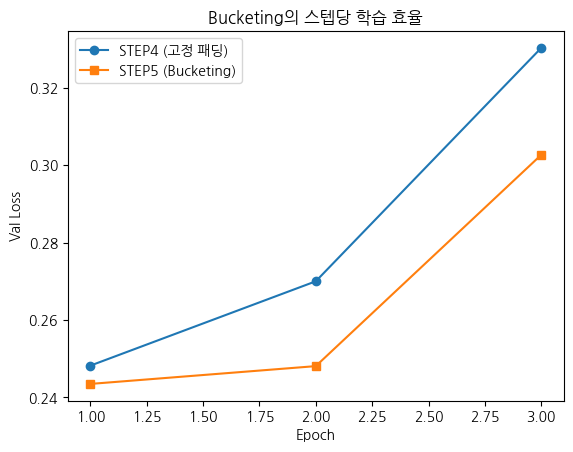

In [45]:
# 학습 스텝
!apt-get -qq install -y fonts-nanum
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False


epochs_range = [1, 2, 3]
step4_val_loss = [0.248184, 0.269987, 0.330313]
step5_val_loss = [0.243458, 0.248059, 0.302675]

plt.plot(epochs_range, step4_val_loss, 'o-', label='STEP4 (고정 패딩)')
plt.plot(epochs_range, step5_val_loss, 's-', label='STEP5 (Bucketing)')
plt.xlabel('Epoch'); plt.ylabel('Val Loss')
plt.title('Bucketing의 스텝당 학습 효율')
plt.legend()
plt.show()

| Epoch | Bucketing 전 (Val Loss) | Bucketing 후 (Val Loss) | 차이 |
|---|---|---|---|
| 1 | 0.248 | 0.243 | 0.005 |
| 2 | 0.270 | 0.248 | 0.022 |
| 3 | 0.330 | 0.303 | 0.028 |

```
Bucketing 후의 val loss가 매 epoch 더 낮게 나왔고,
그 차이가 epoch이 지날수록 커지는 경향을 보인다.
이는 Bucketing이 속도뿐 아니라 학습 궤적에도 긍정적 영향을 줬을 가능성을 시사하지만,
단일 실행 비교이고 분류층의 랜덤 초기화·배치 구성 순서(group_by_length) 차이가 섞여 있어,
이 차이를 Bucketing만의 효과로 단정하기는 어렵다.
```

#### 결론

```
Bucketing 적용 결과,
학습 시간이 119.8분에서 13.7분으로 8.8배 단축되었으며,
Validation Accuracy는 90.53% → 90.63%로 소폭 상승했다.
(+0.10%p, 통계적으로 유의미한 차이로 보기 어려운 수준)

Bucketing의 이점은 속도(연산 효율성)에 한정되며,
모델의 학습 품질(정확도) 자체를 개선하거나 저해하지 않는다고 볼 수 있다.

두 결과 간의 미세한 성능 차이(+0.10%p)는
Bucketing의 효과라기보다, 랜덤 초기화 및 배치 구성 변화에 따른
자연스러운 변동 범위 내의 차이로 보인다.

Kocmi & Bojar(2017)의 영어-체코어 NMT(신경망 기계번역)에서 보고한 연구 결과에 흥미로운 점이 있다. 
Minibatch Bucketing의 같은 배치 안에 언어적으로 비슷한 문장
(① 문장 길이, ② 등위접속사 개수, ③ 명사 개수, ④ 고유명사 개수, ⑤ 동사 개수)들을 배치하는 시도는
무작위로 구성된 배치와 비교했을 때 아무런 차이도 만들어내지 못했다.

Hugging Face의 메가배치 기반 group by length보다 훨씬 더 극단적인 동질성을 가졌지만, 
유의미한 품질 저하가 관찰되지 않았다는 점은, 본 프로젝트에서 사용한
상대적으로 온건한 Bucketing 방식이 학습 품질에 영향을 주지 않았다는
결론을 뒷받침한다.  
```

[Kocmi & Bojar(2017)] (https://arxiv.org/pdf/1707.09533)